## Step 1 - Init python stuff

In [1]:
import s3fs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" #utilise cpu et non gpu

import tensorflow as tf
print(tf.config.list_physical_devices())
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import TensorBoard

import sys
sys.path.append("/home/onyxia/gen-ai-fwi")
from models.DCGAN    import DCGAN
from callbacks.ImagesCallback import ImagesCallback

import fidle

I0000 00:00:1777112737.318178    9847 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777112737.395520    9847 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777112738.675468    9847 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1777112739.431601    9847 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1777112739.431715    9847 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1777112739.431738    9847 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1777112739.431750    9847 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1777112739.431782    9847 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: vscode-python-gpu-460526-0
I0000 00:00:1777112739.431793    9847 cuda_diagnostics.cc:183] hostname: vscode-python-gpu-460526-0
I0000 00:00:1777112739.432101    9847 cuda_diagnostics.cc:190] libcuda reported version is: 575.57.8
I0000 00:00:1777112739.432161    9847 c

## Step 2 - Parameters

In [2]:
latent_dim    = 128

scale         = .01
epochs        = 5
batch_size    = 32
num_img       = 12
fit_verbosity = 1

## Step 3 - Load data

In [3]:


# =========================================================
# 1. RECHARGEMENT DU PARQUET DEPUIS MINIO
# =========================================================
MY_BUCKET = "matheo"
CHEMIN_FICHIER_OUT = "diffusion/data/fwi_se_spain_28x28.parquet"
VALUE_COL = "fwi-daily-proj"
GRID_SIZE = 28

fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})
with fs.open(f"s3://{MY_BUCKET}/{CHEMIN_FICHIER_OUT}", "rb") as f:
    df_loaded = pd.read_parquet(f)

print(f"DataFrame rechargé : {df_loaded.shape}")
print(df_loaded.head())

# =========================================================
# 2. RECONSTRUCTION DU TENSEUR (N, 28, 28)
# =========================================================
# On trie par (time, lat, lon) pour retrouver exactement l'ordre du ravel
# utilisé lors de la sauvegarde. `meshgrid(se_lon_centers, se_lat_centers)`
# produit LAT variant par ligne, LON variant par colonne ; le ravel parcourt
# donc les lignes (lat fixe, lon croissante) puis les latitudes dans l'ordre
# où elles apparaissent dans se_lat_centers (croissante).
df_sorted = df_loaded.sort_values(["time", "lat", "lon"]).reset_index(drop=True)

# Vérification : chaque date doit avoir exactement 784 pixels
counts = df_sorted.groupby("time").size()
assert (counts == GRID_SIZE * GRID_SIZE).all(), \
    f"Certaines dates n'ont pas {GRID_SIZE*GRID_SIZE} pixels"

# Conversion en tenseur (N, 28, 28)
n_dates = df_sorted["time"].nunique()
X = df_sorted[VALUE_COL].values.reshape(n_dates, GRID_SIZE, GRID_SIZE,1)
dates = np.sort(df_sorted["time"].unique())

print(f"Tenseur X : {X.shape}")   # (N, 28, 28)
print(f"min = {X.min():.3f}, max = {X.max():.3f}, mean = {X.mean():.3f}")


DataFrame rechargé : (10308816, 4)
        time        lat       lon  fwi-daily-proj
0 1970-01-01  37.267857 -8.548214             1.0
1 1970-01-01  37.267857 -8.244643             1.0
2 1970-01-01  37.267857 -7.941071             1.0
3 1970-01-01  37.267857 -7.637500             1.0
4 1970-01-01  37.267857 -7.333929             1.0
Tenseur X : (13149, 28, 28, 1)
min = 0.000, max = 211.122, mean = 15.011


## Step 4 - Visualize data

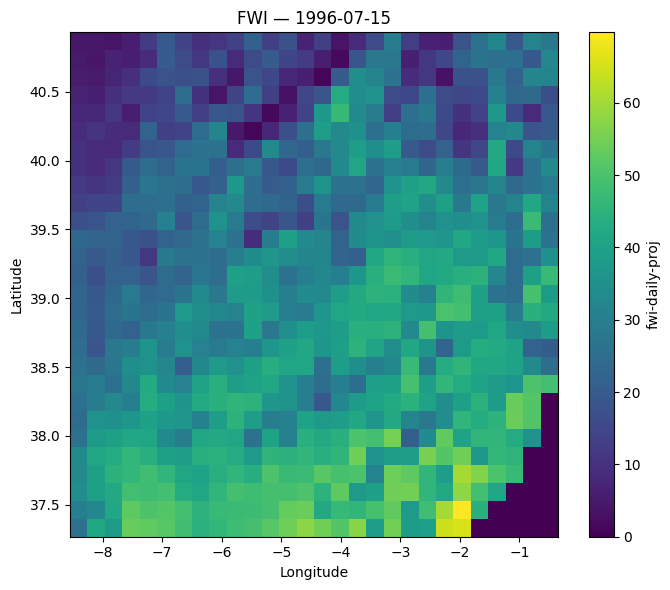

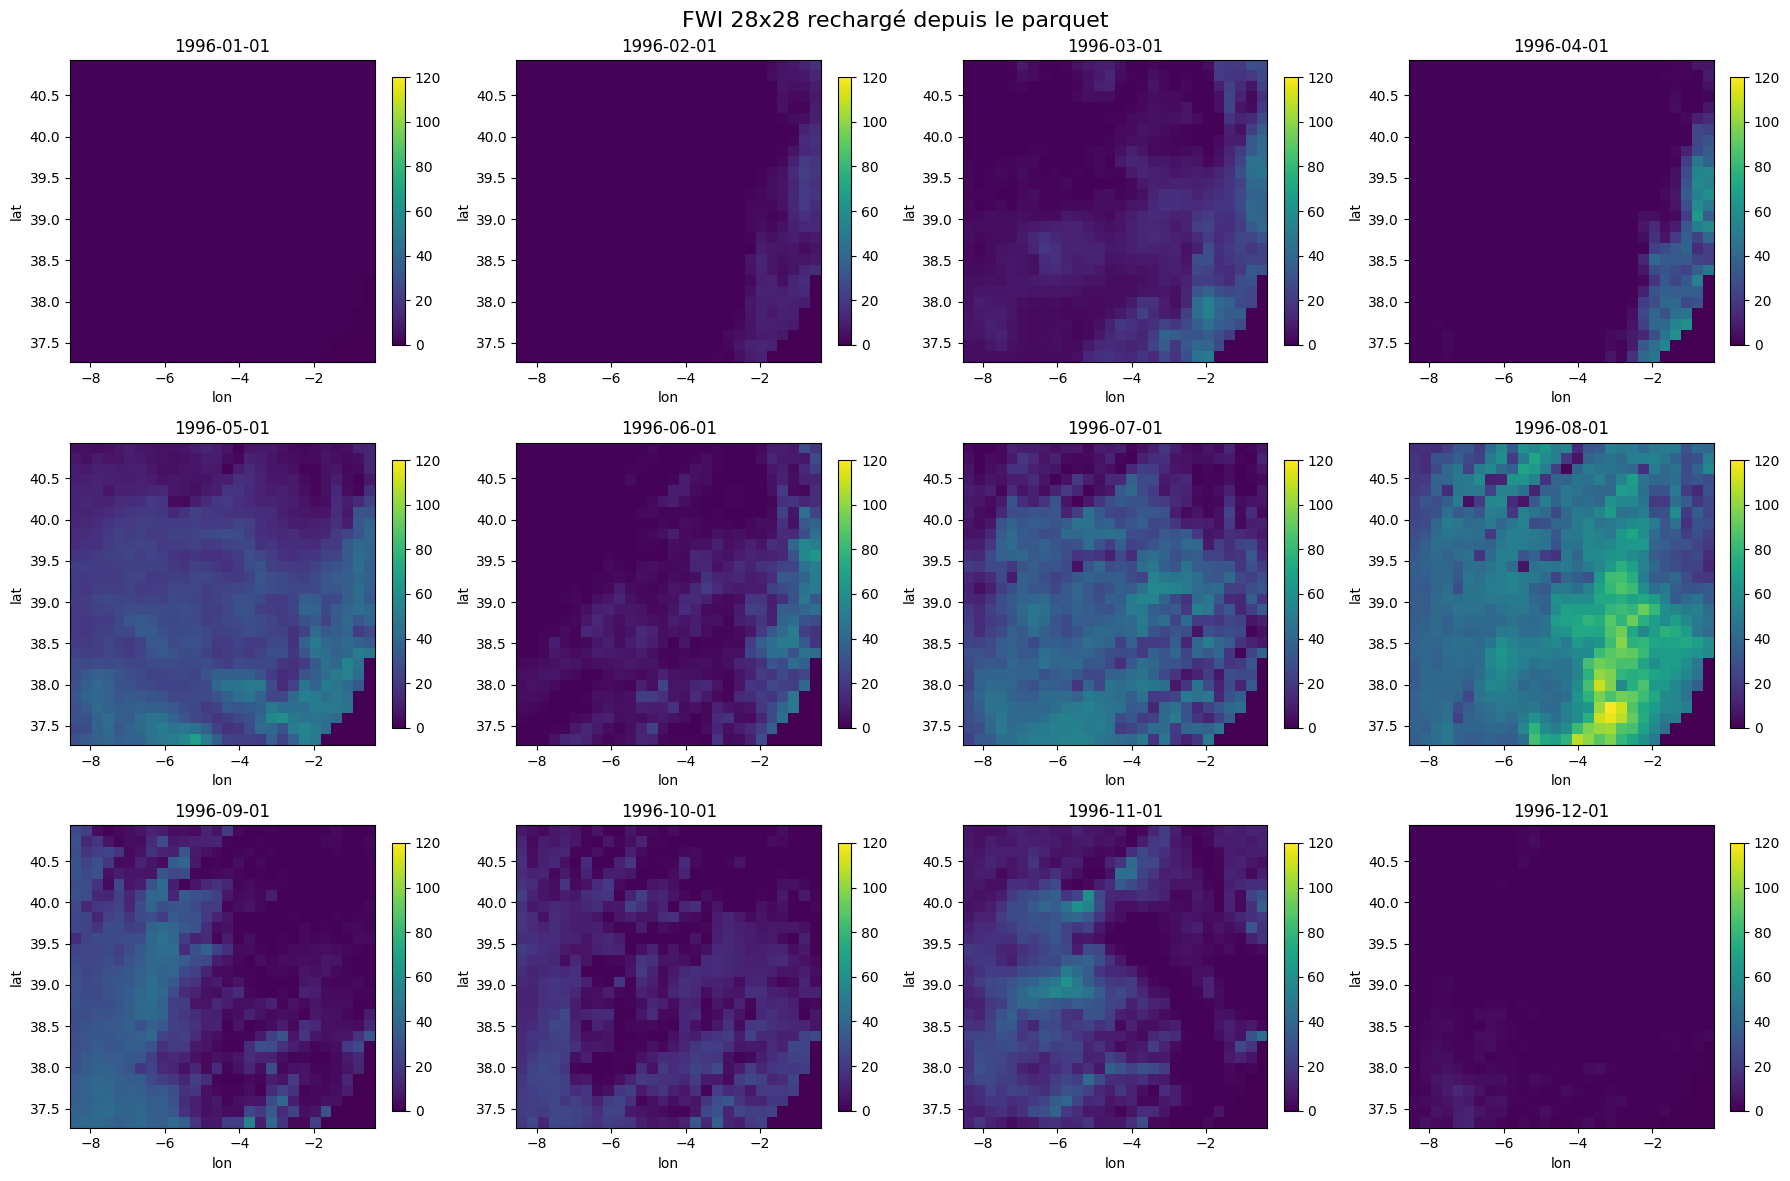

In [4]:
import matplotlib.pyplot as plt

# =========================================================
# 3. RÉAFFICHAGE D'UNE CARTE AVEC COORDONNÉES LON/LAT
# =========================================================
# On récupère les centres de pixels depuis le dataframe rechargé
lon_centers = np.sort(df_loaded["lon"].unique())   # 28 valeurs
lat_centers = np.sort(df_loaded["lat"].unique())   # 28 valeurs
assert len(lon_centers) == GRID_SIZE and len(lat_centers) == GRID_SIZE

# Emprise géographique (pour axer le plot)
extent = [lon_centers.min(), lon_centers.max(),
          lat_centers.min(), lat_centers.max()]

# ---------- Option 1 : une seule date ----------
def plot_one_date(date, X, dates, extent, title_prefix="FWI"):
    i = np.where(dates == np.datetime64(date))[0]
    if len(i) == 0:
        print(f"Date {date} non trouvée dans le dataset.")
        return
    i = i[0]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(X[i], origin="lower", extent=extent,
                   cmap="viridis", aspect="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{title_prefix} — {str(dates[i])[:10]}")
    plt.colorbar(im, ax=ax, label=VALUE_COL)
    plt.tight_layout()
    plt.show()

plot_one_date("1996-07-15", X, dates, extent)


# ---------- Option 2 : grille 3x4 pour les 12 mois de 1996 ----------
dates_plot = ['1996-01-01','1996-02-01','1996-03-01',
              '1996-04-01','1996-05-01','1996-06-01',
              '1996-07-01','1996-08-01','1996-09-01',
              '1996-10-01','1996-11-01','1996-12-01']
dates_plot = [np.datetime64(d) for d in dates_plot]

# Échelle de couleur commune sur les 12 mois
indices = [np.where(dates == d)[0][0] for d in dates_plot if d in dates]
stack = X[indices]
vmin, vmax = stack.min(), stack.max()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for ax, idx in zip(axes, indices):
    im = ax.imshow(X[idx], origin="lower", extent=extent,
                   cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(str(dates[idx])[:10])
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    plt.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle("FWI 28x28 rechargé depuis le parquet", fontsize=16)
plt.tight_layout()
plt.show()

## Step 5 - Create a discriminator

In [5]:
inputs  = keras.Input(shape=(28, 28, 1))
x       = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(inputs)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Flatten()(x)
x       = layers.Dropout(0.2)(x)
z       = layers.Dense(1, activation="sigmoid")(x)
# Stride = 2 to downsample
# padding = "same" to keep the output size the same as input size
# (except for the last layer)

discriminator = keras.Model(inputs, z, name="discriminator")
discriminator.summary()

/opt/python/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,609 (1.51 MB)

 Trainable params: 396,609 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(7 * 7 * 64)(inputs)
x       = layers.Reshape((7, 7, 64))(x)
x       = layers.UpSampling2D()(x)
x       = layers.Conv2D(128,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
x       = layers.UpSampling2D()(x)
x       = layers.Conv2D(256,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
outputs = layers.Conv2D(1,    kernel_size=5, strides=1, padding="same", activation="sigmoid")(x)
#  sigmoid to get output in [0,1] range (because of the normalization of the input images)

# here we use UpSampling2D + Conv2D (to mix the features) instead of Conv2DTranspose
# to avoid checkerboard artifacts

generator = keras.Model(inputs, outputs, name="generator")
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 779,969 (2.98 MB)

 Trainable params: 779,969 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 - Build, compile and train our DCGAN 

In [7]:
gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)

Fidle DCGAN is ready :-)  latent dim = 128


In [8]:
gan.compile(
    discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0001),
    loss_function           = keras.losses.BinaryCrossentropy(),
)

In [9]:
print(X.shape)
print(batch_size)
print(tf.config.list_physical_devices())

(13149, 28, 28, 1)
32
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [10]:
run_dir = './home/onyxia/gen-ai-fwi'

imagesCallback = ImagesCallback(num_img=num_img, latent_dim=latent_dim, run_dir=f'{run_dir}/images')

history = gan.fit( X, 
                   epochs=epochs, 
                   batch_size=batch_size, 
                   callbacks=[imagesCallback], 
                   verbose=fit_verbosity )

gan.save(f'{run_dir}/models/model.h5')

Epoch 1/5


E0000 00:00:1777112746.170796    9847 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/discriminator_1/leaky_re_lu_1_2/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/discriminator_1/conv2d_1_2/BiasAdd'.
E0000 00:00:1777112746.235333    9847 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


411/411 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - d_loss: 0.1369 - g_loss: 3.4792
Epoch 2/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 29s 71ms/step - d_loss: 0.0370 - g_loss: 4.2945
Epoch 3/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - d_loss: 0.0428 - g_loss: 4.3561
Epoch 4/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - d_loss: 0.0408 - g_loss: 4.4567
Epoch 5/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - d_loss: 0.0386 - g_loss: 4.5025


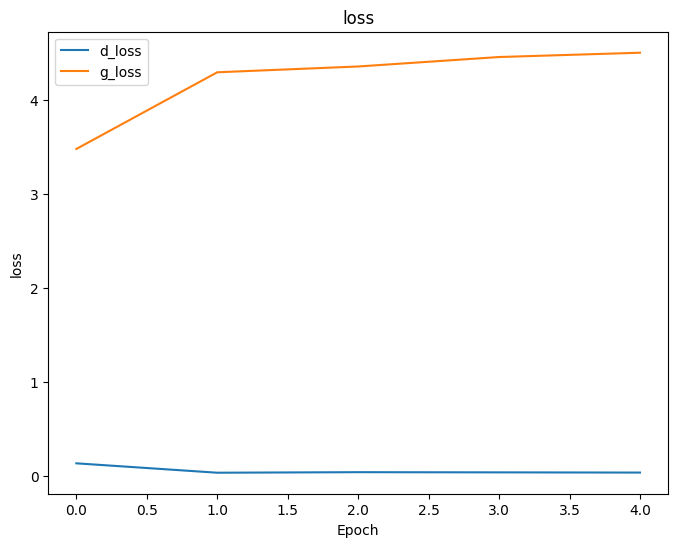

In [11]:
fidle.scrawler.history(history,  plot={'loss':['d_loss','g_loss']}, save_as='01-history')

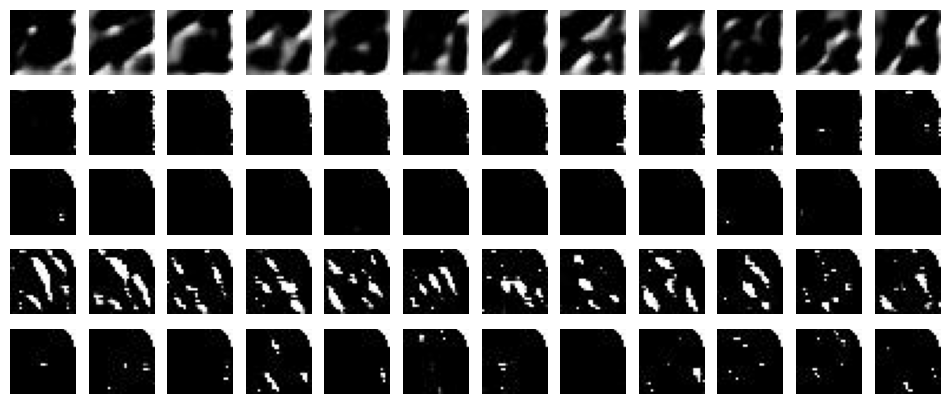

In [12]:
images=[]
for epoch in range(0,epochs,1):
    for i in range(num_img):
        filename = f'{run_dir}/images/image-{epoch:03d}-{i:02d}.jpg'
        image    = io.imread(filename)
        images.append(image)      

fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0, save_as='04-learning')

## Step 8 - Generation
Reload our saved model :

In [13]:
gan.reload(f'{run_dir}/models/model.h5')

Reloaded.


In [15]:
nb_images = 12*15

z = np.random.normal(size=(nb_images,latent_dim))
images = gan.predict(z, verbose=0)


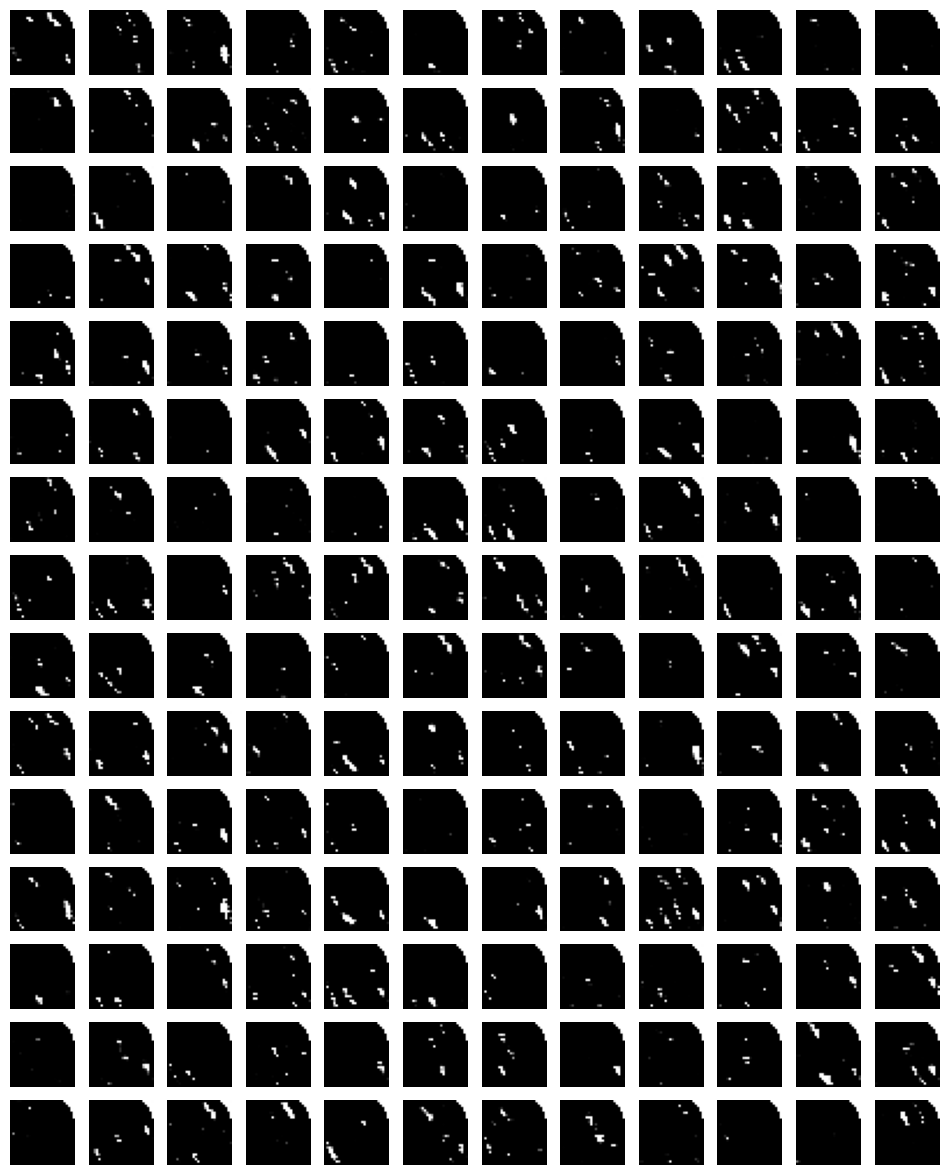

In [16]:
fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0, save_as='04-learning')